# Task 1 — Caption-to-AudioSet classification

This notebook reviews the measured independent-label run and supports reproducible retraining.
MusicCaps `caption` is the only model input; `audioset_positive_labels` supplies independently
annotated audio-event targets. `ytid` is preserved for alignment and split auditing.
The 70/15/15 **ID split precedes vocabulary fitting**, and **thresholds are fitted on validation only**.

The former keyword-derived experiment is preserved in `task1_lexical_proxy.ipynb`,
`Task1_test/`, and `results/task1/notebook_run/`; its near-perfect scores concern a different task.

## 1. Environment

In [1]:
from pathlib import Path
from datetime import datetime
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from src.task1.audioset import load_prepared_manifest, save_audioset_dataset
from src.task1.data import load_musiccaps
from src.task1.evaluate import verify_run
from src.task1.predict import load_checkpoint, predict
from src.task1.train import Task1Config, load_tag_data, train

torch.set_num_threads(6)
print('Repository:', ROOT)
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

C:\Users\Roman\OneDrive\Documents\Neural_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: C:\Users\Roman\OneDrive\Documents\Neural_Project
PyTorch: 2.13.0+cpu | CUDA: False


## 2. Data and artifact paths

The default paths refer to the completed CPU run. Preparation is opt-in; existing files are never
overwritten. If rebuilding an absent CSV, use the same official metadata, seed and preprocessing
settings; the saved manifest checks its SHA-256 before accepting the data.

In [2]:
DATA_PATH = ROOT / 'data' / 'processed' / 'musiccaps_audioset.csv'
RUN_DIR = ROOT / 'results' / 'task1' / 'audioset_cpu_20260907'
CHECKPOINT_PATH = RUN_DIR / 'best_model.pt'
METRICS_PATH = RUN_DIR / 'metrics.json'
CURVE_PATH = RUN_DIR / 'f1_curve.png'
EXAMPLES_PATH = RUN_DIR / 'example_predictions.json'
RUN_PREPARATION = False
if RUN_PREPARATION:
    raw = load_musiccaps()
    save_audioset_dataset(raw, DATA_PATH, top_k=30, min_train_support=20, seed=42)

manifest = load_prepared_manifest(DATA_PATH)
if manifest is None:
    raise FileNotFoundError('Prepare the independent AudioSet CSV and manifest first.')
metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
names = json.loads((ROOT / 'src/task1/audioset_names.json').read_text(encoding='utf-8'))
print('Target source:', manifest['label_source'])
print('Vocabulary fit partition:', manifest['vocabulary_fit_split'])

Target source: MusicCaps.audioset_positive_labels
Vocabulary fit partition: train


## 3. Training-fitted label vocabulary and ID splits

Sorted unique video IDs are randomly split with seed 42 before label parsing/counting. The top 30
nonconstant labels with at least 20 training positives are selected by training frequency, with
label ID as tie breaker. Every row is retained, including rows with zero selected positives.
No aspect list, label text, ID, or metadata flag enters the encoder input. This random split is
not the official AudioSet train/eval benchmark and does not establish artist-disjoint evaluation.

,split,rows,unique_ids,zero_positive_rows
0,train,3864,3864,188
1,validation,828,828,35
2,test,829,829,34


,ytid,text
0,-0Gj8-vB1q4,The low quality recording features a ballad so...
1,-0SdAVK79lg,This song features an electric guitar as the m...
2,-0vPFx-wRRI,a male voice is singing a melody with changing...


,label_id,label,train,validation,test
0,/m/04rlf,Music,3108,677,679
1,/m/04szw,Musical instrument,462,98,108
2,/m/0342h,Guitar,304,61,80
3,/m/0fx80y,Plucked string instrument,297,60,70
4,/m/015lz1,Singing,235,54,54
5,/m/0l14md,Percussion,152,35,40
6,/m/085jw,"Wind instrument, woodwind instrument",146,28,41
7,/m/01kcd,Brass instrument,143,31,18
8,/m/09x0r,Speech,117,30,24
9,/m/026t6,Drum,108,26,27


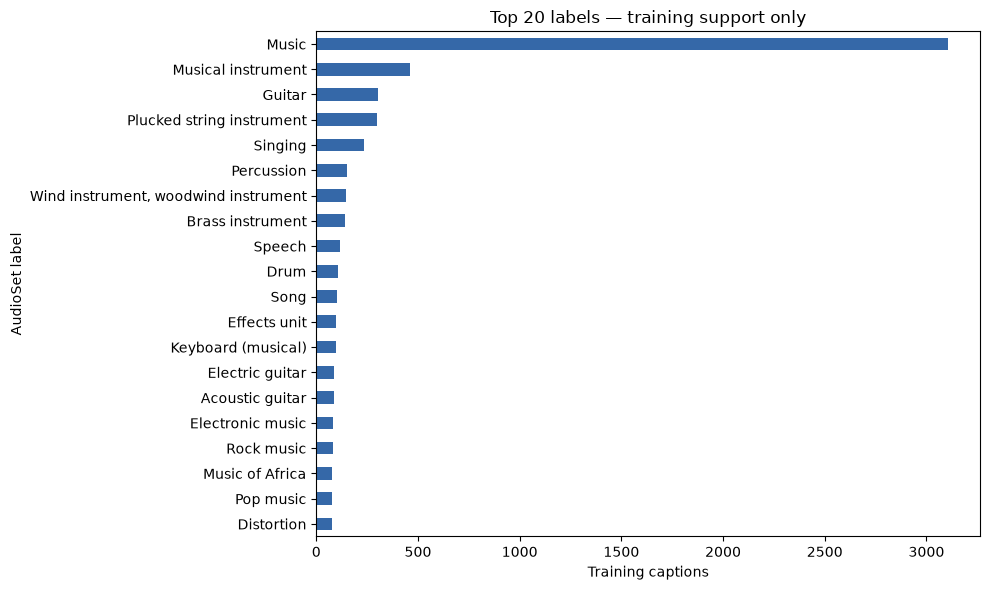

In [3]:
frame = pd.read_csv(DATA_PATH, dtype={'ytid': str})
texts, labels, label_names = load_tag_data(DATA_PATH)
splits = manifest['split_indices']
id_sets = {name: set(frame.iloc[indices].ytid) for name, indices in splits.items()}
assert all(not id_sets[a] & id_sets[b] for a, b in [('train', 'validation'), ('train', 'test'), ('validation', 'test')])
assert sum(len(indices) for indices in splits.values()) == len(frame)
assert frame.columns.tolist() == ['ytid', 'text', *label_names]
display(pd.DataFrame([
    {'split': name, 'rows': len(indices), 'unique_ids': len(id_sets[name]),
     'zero_positive_rows': manifest['zero_positive_rows'][name]}
    for name, indices in splits.items()
]))
display(frame[['ytid', 'text']].head(3))
support = pd.DataFrame({
    'label_id': label_names, 'label': [names.get(tag, tag) for tag in label_names],
    **{name: labels[indices].sum(axis=0).astype(int) for name, indices in splits.items()}
})
display(support)
fig, ax = plt.subplots(figsize=(10, 6))
support.head(20).iloc[::-1].plot.barh(x='label', y='train', ax=ax, legend=False, color='#3568a8')
ax.set(title='Top 20 labels — training support only', xlabel='Training captions', ylabel='AudioSet label')
fig.tight_layout()

## 4. Architecture and selection protocol

```text
caption -> DistilBERT tokenizer [B, 128]
        -> pretrained DistilBERT hidden states [B, 128, 768]
        -> CLS [B, 768] -> dropout(0.1) -> linear(768, 30)
        -> BCEWithLogitsLoss against independent AudioSet multi-hot targets
        -> sigmoid probabilities -> validation-fitted per-label thresholds
```

All encoder layers were fine-tuned for two epochs on CPU. Minimum validation BCE selects the
checkpoint. Only then are per-label thresholds selected by validation F1 on the fixed grid
0.05, 0.10, ..., 0.95. Ties select the higher threshold; labels without validation positives
use the validation-selected global threshold. Test inference happens after all model and
threshold selection, including the three classical controls. The history F1 uses the fixed
0.5 threshold; it is not the final calibrated test score.

## 5. Checkpoint and calibration integrity

In [4]:
state, metadata = load_checkpoint(CHECKPOINT_PATH)
del state
if metadata['model_name'] != metrics['config']['model_name']:
    raise ValueError('WARNING: active checkpoint and metrics are from different runs')
assert metadata['tags'] == label_names
assert metadata['thresholds'] == metrics['calibration']['thresholds']
assert metadata['label_source'] == manifest['label_source']
assert metrics['dataset']['sha256'] == manifest['csv_sha256']
print('Best epoch:', metrics['best_epoch'], '| Selection:', metrics['selection_metric'])
print('Threshold fit partition:', metrics['calibration']['fit_split'])
display(pd.DataFrame({'label': support.label, 'threshold': metadata['thresholds']}))

Best epoch: 2 | Selection: validation_bce_loss
Threshold fit partition: validation


,label,threshold
0,Music,0.45
1,Musical instrument,0.35
2,Guitar,0.55
3,Plucked string instrument,0.55
4,Singing,0.05
5,Percussion,0.10
6,"Wind instrument, woodwind instrument",0.25
7,Brass instrument,0.20
8,Speech,0.10
9,Drum,0.20


## 6. Measured held-out results and controls

All rows below use the same 829 test IDs and 30-label vocabulary. Macro-F1 is an unweighted
mean over all labels. mAP is the mean of per-label average precision (not trapezoidal PR AUC);
labels with zero evaluation positives have null AP and are excluded from mAP. All 30 labels
have test positives in this run. The TF-IDF vocabulary, IDF weights and logistic classifiers
are fitted on training captions only. The keyword control uses fixed official ontology names.

,model,Macro-F1,Micro-F1,mAP
0,DistilBERT (2 epochs),0.3840,0.5902,0.3686
1,label_prior,0.0528,0.3530,0.0591
2,ontology_keyword,0.1568,0.2257,0.1158
3,tfidf_logistic,0.3393,0.6530,0.3603


,epoch,train_loss,val_loss,train_macro_f1,train_micro_f1,val_macro_f1,val_micro_f1
0,1,0.171760,0.101907,0.068333,0.502683,0.131293,0.680655
1,2,0.098593,0.090148,0.189205,0.687348,0.208024,0.707523


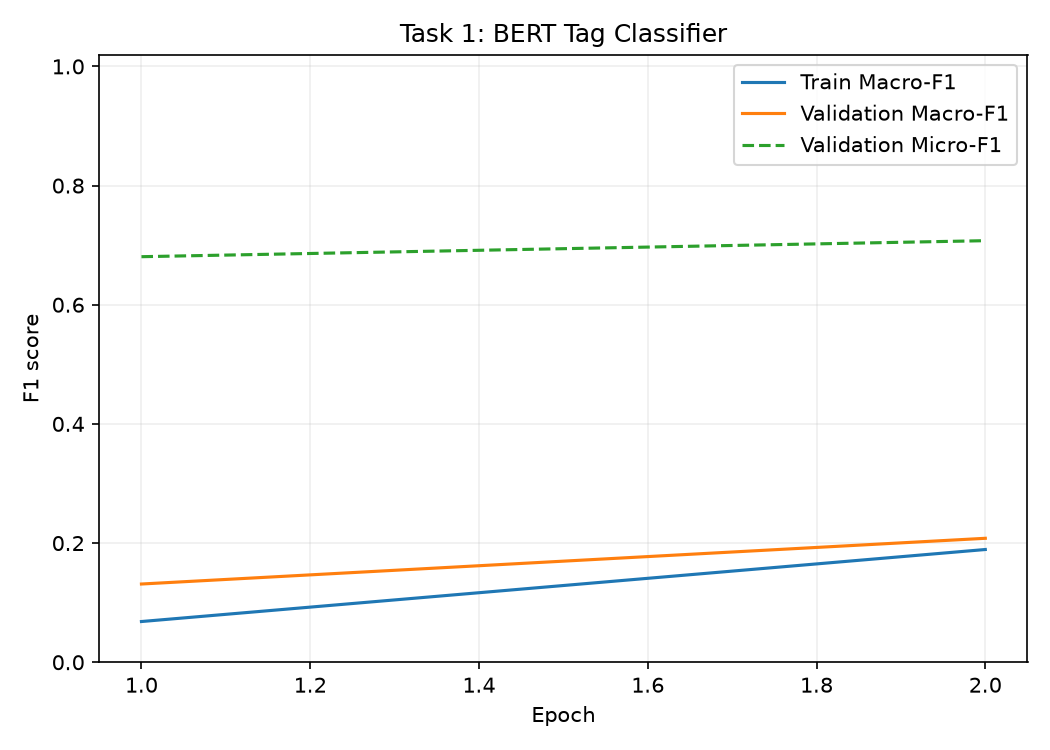

Measured elapsed minutes: 24.35


In [5]:
reports = {'DistilBERT (2 epochs)': metrics['test'],
           **{name: item['test'] for name, item in metrics['baselines'].items()}}
table = pd.DataFrame([
    {'model': name, 'Macro-F1': report['macro_f1'], 'Micro-F1': report['micro_f1'],
     'mAP': report['mean_average_precision']}
    for name, report in reports.items()
])
display(table.style.format({'Macro-F1': '{:.4f}', 'Micro-F1': '{:.4f}', 'mAP': '{:.4f}'}))
display(pd.DataFrame(metrics['history']))
display(Image(filename=str(CURVE_PATH)))
print('Measured elapsed minutes:', round(metrics['runtime']['seconds'] / 60, 2))

DistilBERT has higher Macro-F1 and mAP than these controls, while TF-IDF has higher Micro-F1.
Calibrating for Macro-F1 trades off micro performance: the same BERT probabilities at a fixed
0.5 threshold give Macro-F1 0.1999 and Micro-F1 0.6791. This comparison is descriptive;
thresholds were not changed after examining test results. A frequent `Music` label contributes
strongly to Micro-F1. One seed and two CPU epochs do not establish convergence or superiority
over a tuned TF-IDF system.

## 7. Five saved examples

In [6]:
# Load examples here so this cell also works in a fresh kernel.
import json
from pathlib import Path

if 'EXAMPLES_PATH' not in globals():
    example_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Task1_test' / 'files').is_dir()), None)
    if example_root is None:
        raise FileNotFoundError('Open this notebook from the Neural_Project folder or set EXAMPLES_PATH to example_predictions.json.')
    EXAMPLES_PATH = example_root / 'results' / 'task1' / 'audioset_cpu_20260907' / 'example_predictions.json'
saved_examples = json.loads(Path(EXAMPLES_PATH).read_text(encoding='utf-8'))
def prediction_pairs(items):
    return [(item['tag'], item['probability']) if isinstance(item, dict) else item if isinstance(item, str) else tuple(item) for item in items]

for number, example in enumerate(saved_examples, start=1):
    print(f'Example {number}')
    print('Caption:', example['text'][:240] + ('...' if len(example['text']) > 240 else ''))
    print('True AudioSet IDs:', example['true_tags'])
    print('Top predicted:', prediction_pairs(example['top_predicted']))
    print('-' * 80)

Example 1
Caption: The Pop song features a soft female vocal singing over sustained pulsating synth lead, mellow piano melody, sustained synth brass, punchy kick, claps. tinny wide hi hats and high pitched female vocal melody. It sounds emotional, sad, passio...
True AudioSet IDs: ['/m/04rlf']
Top predicted: [('/m/04rlf', 0.9342), ('/m/015lz1', 0.1086), ('/m/074ft', 0.0644), ('/m/0164x2', 0.0611), ('/m/064t9', 0.0527)]
--------------------------------------------------------------------------------
Example 2
Caption: This is an R&B/soul music piece. There is a male vocalist singing melodically and in a sensual manner over multiple tracks. The melody of the beat is provided by a string sample. There is a strong bass sound in the piece. The rhythm is prov...
True AudioSet IDs: ['/m/04rlf']
Top predicted: [('/m/04rlf', 0.9427), ('/m/0164x2', 0.0808), ('/m/015lz1', 0.0647), ('/m/0glt670', 0.0595), ('/m/02x8m', 0.0358)]
-----------------------------------------------------------------------

## 8. Per-label errors and uncertainty

In [7]:
verification = json.loads((RUN_DIR / 'verification.json').read_text(encoding='utf-8'))
analysis = json.loads((RUN_DIR / 'error_analysis.json').read_text(encoding='utf-8'))
print('Saved predictions independently verified:', verification['verified'])
print('BERT bootstrap intervals:', verification['models']['distilbert'])
display(pd.DataFrame(analysis['five_highest_sample_f1']))
display(pd.DataFrame(analysis['five_lowest_sample_f1']))
display(pd.DataFrame(metrics['test']['per_tag']).T.rename(index=names))
print('Excluding Music root, descriptive Micro-F1:', analysis['excluding_music_root_descriptive']['micro_f1'])

Saved predictions independently verified: True
BERT bootstrap intervals: {'method': 'test-row percentile bootstrap; fixed fitted model and thresholds', 'repeats': 1000, 'seed': 2026, 'macro_f1_95_ci': [0.3498785160972653, 0.41123077977916234], 'micro_f1_95_ci': [0.5709408394146245, 0.6094618553043735]}


,ytid,text,sample_f1,true_tags,predicted_tags,missed,extra
0,-DeAdhYKbGE,A bagpipe ensemble playing a quick melody in u...,1.0,"[Wind instrument, woodwind instrument]","[Wind instrument, woodwind instrument]",[],[]
1,-SWaCArvQug,Ambient sound still in the room with a mild ba...,1.0,[Music],[Music],[],[]
2,0RgGrVklaao,This clip is an instrumental of two separate t...,1.0,[Music],[Music],[],[]
3,0ZNFJz-eZTU,The low quality recording features a jazz song...,1.0,[Brass instrument],[Brass instrument],[],[]
4,0lIETNZ_7sg,The low quality recording features a Christmas...,1.0,[Music],[Music],[],[]


,ytid,text,sample_f1,true_tags,predicted_tags,missed,extra
0,-7wUQP6G5EQ,The low quality recording features a renaissan...,0.0,[Music],[],[Music],[]
1,-FEPOSP7ay0,The low quality recording features loud bells ...,0.0,[],[Music],[],[Music]
2,-f1DNyngKVY,This is an instrumental sitar music piece. The...,0.0,[Music],[Percussion],[Music],[Percussion]
3,0Wdh45yt7tY,The song is an instrumental. The song is mediu...,0.0,"[Wind instrument, woodwind instrument]",[],"[Wind instrument, woodwind instrument]",[]
4,1GCOnj53QYM,This music is two separate tracks. The first t...,0.0,[],[Music],[],[Music]


,precision,recall,f1,support,auc_pr
Music,0.880920,0.958763,0.918195,679.0,0.934223
Musical instrument,0.588889,0.490741,0.535354,108.0,0.505804
Guitar,0.750000,0.600000,0.666667,80.0,0.721015
Plucked string instrument,0.656250,0.600000,0.626866,70.0,0.669509
Singing,0.181818,0.888889,0.301887,54.0,0.236681
Percussion,0.409091,0.450000,0.428571,40.0,0.437504
"Wind instrument, woodwind instrument",0.870968,0.658537,0.750000,41.0,0.808293
Brass instrument,0.500000,0.722222,0.590909,18.0,0.524547
Speech,0.294118,0.208333,0.243902,24.0,0.174051
Drum,0.411765,0.259259,0.318182,27.0,0.303642


Excluding Music root, descriptive Micro-F1: 0.37183098591549296


The five highest/lowest sample-F1 cases are selected mechanically after evaluation. Missing
annotations can appear as false positives: AudioSet positive labels do not guarantee exhaustive
negative annotation. Confidence intervals resample the fixed test IDs and do not capture training
seed variability. Exact ontology-name overlap is also reported in `error_analysis.json`; the
frequent `Music` label influences this stratification, so it is not a causal leakage experiment.

## 9. Inference with saved thresholds

In [8]:
RUN_INFERENCE = True
if RUN_INFERENCE:
    predictions = predict(
        ['calm acoustic guitar with soft vocals',
         'energetic electronic music with synthesizer and fast drums',
         'slow melancholic piano instrumental'], CHECKPOINT_PATH, top_k=5,
    )
    display(pd.DataFrame({
        'caption': [item['text'] for item in predictions],
        'predicted_labels': [[tag['display_name'] for tag in item['predicted_tags']] for item in predictions],
        'top_probabilities': [[(tag['display_name'], tag['probability']) for tag in item['top_tags']] for item in predictions],
    }))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13890.26it/s]


[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,caption,predicted_labels,top_probabilities
0,calm acoustic guitar with soft vocals,"[Music, Singing, Rock music]","[(Music, 0.9558), (Guitar, 0.4125), (Plucked s..."
1,energetic electronic music with synthesizer an...,[Music],"[(Music, 0.9266), (Electronic music, 0.0773), ..."
2,slow melancholic piano instrumental,[],"[(Music, 0.3523), (Keyboard (musical), 0.2637)..."


## 10. Optional retraining and verification

Retraining is opt-in and writes to a fresh timestamped directory. It retains the prepared ID
split and vocabulary on either CPU or CUDA. The measured table above continues to show the
fixed completed run; it is not silently replaced by a new experiment.

In [9]:
RUN_TRAINING = False
TRAIN_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TRAIN_EPOCHS = 10 if TRAIN_DEVICE == 'cuda' else 2
if RUN_TRAINING:
    NOTEBOOK_RUN_DIR = ROOT / 'results/task1' / ('audioset_notebook_' + datetime.now().strftime('%Y%m%d_%H%M%S'))
    notebook_metrics = train(Task1Config(
        data_path=str(DATA_PATH), output_dir=str(NOTEBOOK_RUN_DIR),
        model_name='distilbert-base-uncased', max_length=128, batch_size=16,
        epochs=TRAIN_EPOCHS, patience=3, seed=42, device=TRAIN_DEVICE,
        cpu_threads=6, tune_thresholds=True, run_baselines=True,
    ))
    verify_run(NOTEBOOK_RUN_DIR)
    print('New run:', NOTEBOOK_RUN_DIR)

RUN_RECOMPUTATION = False
if RUN_RECOMPUTATION:
    verification = verify_run(RUN_DIR)
    print(verification)

## Interpretation and sources

This is caption-based prediction of independently supplied audio-event annotations. It does not
show that the text model listened to audio, predict a validated mood taxonomy, establish artist
generalization, or remove lexical shortcuts from captions. AudioSet labels are sparse and the
random ID partition is not multilabel-stratified. Do not compare the old proxy F1 directly with
these independent-label scores. Changes to Tasks 2–4 require explicitly aligning IDs, targets
and splits to this new manifest before any multimodal comparison.

- [Official MusicCaps metadata and CC BY-SA 4.0 license](https://huggingface.co/datasets/google/MusicCaps)
- [AudioSet metadata and label definitions](https://research.google.com/audioset/download.html)
- Repository: `docs/task1/README.md`, `report/task1_results.md`, `results/task1/audioset_cpu_20260907/`.